##ENTENDIMIENTO DE LOS DATOS



In [45]:
#Importar librerías

import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf, quarter_plot, month_plot

In [6]:
#Cargar los datos (no se puede hacer directamente con pandas)

def leer_datos_consumo(archivo, hoja):
    """
    Lee los datos de consumo de una hoja específica del archivo Excel.

    Parámetros:
    -----------
    archivo : str
        Ruta al archivo Excel
    hoja : str
        Nombre de la hoja a leer (METRO_ENV, METRO_SAND o METRO_ZAMO)

    Retorna:
    --------
    DataFrame con las siguientes columnas:
    - Fecha: fecha en formato datetime
    - H1, H2, ..., H24: consumo por hora en kWh (NaN si falta)
    - Total: suma de las 24 horas (NaN si falta)
    """

    # Cargar el workbook con openpyxl para manejar celdas fusionadas
    wb = openpyxl.load_workbook(archivo, data_only=True)
    ws = wb[hoja]

    # La tabla comienza en la fila 16 (encabezados) y 17 (datos)
    fila_inicio_datos = 17

    # Leer datos fila por fila
    datos = []

    for fila in range(fila_inicio_datos, ws.max_row + 1):
        # La fecha está en la columna B (columna 2), pero fusionada en B:D
        fecha = ws.cell(row=fila, column=2).value

        # Si no hay fecha, hemos llegado al final de los datos
        if fecha is None or not isinstance(fecha, str):
            break

        # Leer las 24 horas de consumo
        fila_datos = {'Fecha': fecha}

        # Mapeo de las columnas de horas
        columnas_horas = [
            5,   # H1 (E)
            7,   # H2 (G)
            8,   # H3 (H)
            9,   # H4 (I)
            12,  # H5 (L)
            14,  # H6 (N)
            16,  # H7 (P)
            21,  # H8 (U)
            22,  # H9 (V)
            23,  # H10 (W)
            24,  # H11 (X)
            25,  # H12 (Y)
            26,  # H13 (Z)
            27,  # H14 (AA)
            28,  # H15 (AB)
            29,  # H16 (AC)
            30,  # H17 (AD)
            31,  # H18 (AE)
            32,  # H19 (AF)
            33,  # H20 (AG)
            34,  # H21 (AH)
            35,  # H22 (AI)
            36,  # H23 (AJ)
            37,  # H24 (AK)
        ]

        # Leer cada hora
        for i, col in enumerate(columnas_horas, 1):
            valor = ws.cell(row=fila, column=col).value
            fila_datos[f'H{i}'] = valor  # Si es None, queda None

        # La columna total está en AL (38)
        total = ws.cell(row=fila, column=38).value
        fila_datos['Total'] = total  # Si es None, queda None

        datos.append(fila_datos)

    # Crear DataFrame
    df = pd.DataFrame(datos)

    # Convertir fecha a datetime
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

    # Asegurar que las columnas de consumo sean numéricas
    columnas_numericas = [f'H{i}' for i in range(1, 25)] + ['Total']
    for col in columnas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    wb.close()

    return df


archivo1 = 'Consumos 2018-2020.xlsx'
archivo2 = 'Consumos 2023-2024.xlsx'
archivo3 = 'Consumos 2021-2022.xlsx'
archivo4 = 'Consumos 2025.xlsx'


#Leer las tres hojas con los consumos de las plantas (ENVIGADO, SAN DIEGO, ZAMORA) en todos los intervalos de tiempo
df_env1 = leer_datos_consumo(archivo1, 'METRO_ENV')
df_env2 = leer_datos_consumo(archivo2, 'METRO_ENV')
df_env3 = leer_datos_consumo(archivo3, 'METRO_ENV')
df_env4 = leer_datos_consumo(archivo4, 'METRO_ENV')

df_zamo1 = leer_datos_consumo(archivo1, 'METRO_ZAMO')
df_zamo2 = leer_datos_consumo(archivo2, 'METRO_ZAMO')
df_zamo3 = leer_datos_consumo(archivo3, 'METRO_ZAMO')
df_zamo4 = leer_datos_consumo(archivo4, 'METRO_ZAMO')

df_sand1 = leer_datos_consumo(archivo1, 'METRO_SAND')
df_sand2 = leer_datos_consumo(archivo2, 'METRO_SAND')
df_sand3 = leer_datos_consumo(archivo3, 'METRO_SAND')
df_sand4 = leer_datos_consumo(archivo4, 'METRO_SAND')

#Concatenar los dataframes

df_env = pd.concat([df_env1, df_env2, df_env3, df_env4], ignore_index=True)
df_zamo = pd.concat([df_zamo1, df_zamo2, df_zamo3, df_zamo4], ignore_index=True)
df_sand = pd.concat([df_sand1, df_sand2, df_sand3, df_sand4], ignore_index=True)


"""df_sand = leer_datos_consumo(archivo1, 'METRO_SAND')
df_zamo = leer_datos_consumo(archivo1, 'METRO_ZAMO')

#La fecha tiene que estar en orden para series temporales (para estar seguros)
df_env = df_env.sort_values("Fecha").reset_index(drop=True)
df_sandiego = df_sand.sort_values("Fecha").reset_index(drop=True)
df_zamora = df_zamo.sort_values("Fecha").reset_index(drop=True)"""


'df_sand = leer_datos_consumo(archivo1, \'METRO_SAND\')\ndf_zamo = leer_datos_consumo(archivo1, \'METRO_ZAMO\')\n\n#La fecha tiene que estar en orden para series temporales (para estar seguros)\ndf_envigado = df_env.sort_values("Fecha").reset_index(drop=True)\ndf_sandiego = df_sand.sort_values("Fecha").reset_index(drop=True)\ndf_zamora = df_zamo.sort_values("Fecha").reset_index(drop=True)'

In [51]:
# Ordenar la serie
df_env = df_env.sort_values("Fecha").reset_index(drop=True)
df_sand = df_sand.sort_values("Fecha").reset_index(drop=True)
df_zamo = df_zamo.sort_values("Fecha").reset_index(drop=True)

#Visualizar el dataset de ENVIGADO
df_env

,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
0,2018-01-01,164.9999,164.9999,161.3332,164.9999,183.3336,718.6671,2126.6671,1903.0000,2005.6670,...,1987.3335,2053.3338,1936.0004,2016.6670,2035.0004,1939.6668,1961.6671,1323.6671,168.6666,35079.0064
1,2018-01-02,157.6667,157.6667,150.3337,249.3332,1569.3336,4205.6678,4374.3343,4484.3346,3534.6676,...,3633.6676,4675.0011,5093.0014,4675.0010,4550.3343,2783.0006,2456.6671,2343.0006,902.0003,69230.3502
2,2018-01-03,198.0002,194.3337,194.3337,234.6669,1723.3338,4414.6678,4836.3346,4649.3346,3732.6677,...,3809.6676,4517.3343,4788.6675,5008.6678,3637.3341,2596.0007,2207.3338,2101.0006,828.6669,70323.0178
3,2018-01-04,205.3332,201.6667,198.0002,245.6667,1694.0006,4216.6679,4455.0008,4165.3343,3927.0008,...,3443.0011,4880.3346,4928.0013,5071.0011,4253.3341,2647.3341,2361.3341,2174.3339,898.3334,69131.3509
4,2018-01-05,216.3333,212.6666,208.9999,293.3334,1595.0006,4257.0009,4766.6681,4455.0013,3600.6677,...,3820.6678,4554.0011,5115.0011,5239.6679,4147.0008,2717.0006,2431.0008,2346.6670,902.0001,70741.0171
5,2018-01-06,212.6666,205.3332,201.6667,297.0002,1595.0006,4249.6676,4297.3343,4301.0008,3890.3343,...,4264.3343,4297.3343,4367.0009,3311.0009,3512.6676,2955.3341,2504.3339,2053.3340,894.6671,68104.6828
6,2018-01-07,176.0000,179.6668,179.6668,176.0000,810.3338,1976.3338,2236.6671,2126.6671,2130.3338,...,2940.6674,3149.6676,3237.6674,3281.6675,3083.6674,2665.6674,2438.3338,1752.6671,209.0004,49808.0125
7,2018-01-08,183.3336,183.3336,187.0004,183.3336,781.0006,1976.3338,2174.3338,2031.3338,2016.6671,...,3076.3344,3083.6673,3186.3342,3116.6674,2823.3342,2533.6674,2207.3338,1602.3336,201.6672,48202.0148
8,2018-01-09,187.0004,187.0004,187.0004,311.6669,1635.3339,5316.6676,5034.3348,5415.6679,4180.0009,...,3080.0007,2915.0008,2797.6673,3432.0009,3083.6677,2522.6671,2060.6671,1811.3336,641.6666,63605.6831
9,2018-01-10,205.3332,205.3332,201.6667,363.0001,975.3335,3116.6676,3556.6677,3699.6676,3325.6677,...,4752.0013,5555.0011,5984.0013,4946.3346,5434.0013,3369.6678,2489.6673,2130.3341,924.0001,69707.0175


In [19]:
#Ver la información de cada columna del dataset (ENVIGADO)
df_env.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Fecha   2922 non-null   datetime64[ns]
 1   H1      2922 non-null   float64       
 2   H2      2922 non-null   float64       
 3   H3      2922 non-null   float64       
 4   H4      2922 non-null   float64       
 5   H5      2922 non-null   float64       
 6   H6      2922 non-null   float64       
 7   H7      2922 non-null   float64       
 8   H8      2922 non-null   float64       
 9   H9      2922 non-null   float64       
 10  H10     2922 non-null   float64       
 11  H11     2922 non-null   float64       
 12  H12     2922 non-null   float64       
 13  H13     2922 non-null   float64       
 14  H14     2922 non-null   float64       
 15  H15     2922 non-null   float64       
 16  H16     2922 non-null   float64       
 17  H17     2922 non-null   float64       
 18  H18     

In [18]:
#Ver estadísticas descriptivas del dataset (ENVIGADO)
df_env.describe(include="all")

,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
count,2922,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,...,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,2021-12-31 12:00:00,271.254787,252.883521,249.758709,299.813424,1559.407714,4266.145104,4819.732233,4740.257706,3997.470904,...,3918.052873,4393.832727,4596.194545,4422.017258,3780.571065,3099.862357,2588.717368,2152.006585,940.169942,68916.739426
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-01-01 06:00:00,205.333200,201.667200,201.666900,220.000100,1218.250525,3880.222725,4265.250700,4154.334025,3506.250800,...,3527.333825,4033.334000,3892.167625,3666.667125,3072.667400,2691.333950,2262.333600,1924.681850,766.360000,66396.004150
50%,2021-12-31 12:00:00,238.333700,234.667200,234.666900,271.333700,1635.333600,4568.667050,5445.001300,5393.668100,4335.834450,...,4109.641650,4766.667150,5085.667400,4876.667350,4086.500900,3223.000600,2585.001050,2222.000650,931.333600,75164.847950
75%,2023-12-31 18:00:00,284.891875,278.323700,274.990225,366.667200,1925.000300,5133.334000,5786.000750,5738.334000,4766.667800,...,4554.000600,5159.001150,5529.335125,5309.334250,4451.103200,3597.001050,2958.083525,2478.667100,1216.875200,78100.016800
max,2025-12-31 00:00:00,1818.667100,1738.000400,1763.667100,1180.667100,3666.667200,8169.335600,8609.335500,8635.002300,7252.668300,...,7003.335100,8231.669100,8712.002400,8466.335600,8407.668900,5551.334800,4620.000900,4165.334600,3043.334100,122503.366500
std,NaN,179.030590,140.005527,126.909259,130.479157,563.867367,1201.760686,1389.514652,1409.708707,1088.336183,...,978.099953,1173.319692,1297.422762,1237.198330,974.716355,690.780600,563.508302,498.858300,479.910122,15190.891829


**IMPORTANTE**: Analice los patrones interesantes que se vean en el describe y póngalos en contexto del problema que estamos abordando (ENVIGADO).

Hacer lo mismo para las otras dos plantas eléctricas (Sand Diego y Zamora)

In [ ]:
#Pon tu código aquí

###Dimensiones de calidad

In [20]:
#Completetitud

# Columnas horarias
cols_horas = [f'H{i}' for i in range(1,25)]

# Se crea la lista de fechas deberia de comprender la columna 'Fecha'
rango_fechas = pd.date_range(
    start=df_env['Fecha'].min(),
    end=df_env['Fecha'].max(),
    freq='D'
)

#Se comparan las fechas que deberían de existir en en dataset con las que de verdad hay
fechas_faltantes = rango_fechas.difference(df_env['Fecha'])

print("Días faltantes:", len(fechas_faltantes))


Días faltantes: 0


In [21]:
#Conformidad o validez

negativos = (df_env[cols_horas] < 0).sum().sum()

print("Cantidad de registros negativos:", negativos)

Cantidad de registros negativos: 0


In [23]:
#Consistencia

df_env['suma_horas'] = df_env[cols_horas].sum(axis=1)

df_env['error_total'] = df_env['Total'] - df_env['suma_horas']

inconsistentes = df_env[np.abs(df_env['error_total']) > 1e-8]

print("Días inconsistentes:", len(inconsistentes))

df_env = df_env.drop(columns=['suma_horas', 'error_total'])

Días inconsistentes: 0


In [ ]:
#Precisión/Exactitud (creo que no aplica)

In [ ]:
#Duplicidad (ya se verifica en completitud)

In [ ]:
#Integridad (no creo que aplique y si lo hace ya se hizo en las anteriores)

In [24]:
#Detercción de outliers (univariados - poner, al menos, 3 métodos)

outliers_iqr_hora = {}

for col in cols_horas:

    Q1 = df_env[col].quantile(0.25)
    Q3 = df_env[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    mask = (df_env[col] < lim_inf) | (df_env[col] > lim_sup)

    outliers_iqr_hora[col] = mask.sum()

outliers_iqr_hora = pd.Series(outliers_iqr_hora)


print("\nTotal:", outliers_iqr_hora.sum())
outliers_iqr_hora


Total: 3730


,0
H1,284
H2,269
H3,250
H4,89
H5,49
H6,174
H7,73
H8,50
H9,52
H10,80


In [25]:
outliers_z_hora = {}

for col in cols_horas:

    mean = df_env[col].mean()
    std = df_env[col].std()

    z_scores = (df_env[col] - mean) / std

    mask = np.abs(z_scores) > 3

    outliers_z_hora[col] = mask.sum()

outliers_z_hora = pd.Series(outliers_z_hora)


print("\nTotal:", outliers_z_hora.sum())
outliers_z_hora


Total: 1026


,0
H1,77
H2,59
H3,60
H4,53
H5,3
H6,39
H7,33
H8,33
H9,34
H10,39


In [26]:
outliers_pct_hora = {}

for col in cols_horas:

    p1 = df_env[col].quantile(0.01)
    p99 = df_env[col].quantile(0.99)

    mask = (df_env[col] < p1) | (df_env[col] > p99)

    outliers_pct_hora[col] = mask.sum()

outliers_pct_hora = pd.Series(outliers_pct_hora)


print("\nTotal:", outliers_pct_hora.sum())
outliers_pct_hora



Total: 1284


,0
H1,30
H2,30
H3,30
H4,30
H5,60
H6,60
H7,60
H8,59
H9,60
H10,60


In [ ]:
#Importancia de variables (cuando lo vemos de forma no contínua) - CONSULTAR

In [ ]:
#Escalamiento - CONSULTAR (en caso de que aplique)

In [56]:
#Poner los datos de forma continua

def datos_continuos(
    df,
    fecha_col="Fecha",
    prefix_horas="H",
    n_horas=24
):
    """
    Convierte un dataframe en formato ancho (H1…H24) a serie de tiempo horaria.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset original.

    fecha_col : str
        Nombre de la columna de fecha.

    prefix_horas : str
        Prefijo de las columnas horarias (en nuestro caso 'H').

    n_horas : int
        Número de horas (default 24).

    """

    df = df.copy()

    # --- 1. Fecha a datetime ---
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    # --- 2. Columnas horarias ---
    cols_horas = [f"{prefix_horas}{i}" for i in range(1, n_horas + 1)]

    df_horas = df[[fecha_col] + cols_horas]

    # - Wide → Long ---
    df_long = df_horas.melt(
        id_vars=fecha_col,
        value_vars=cols_horas,
        var_name="Hora",
        value_name="Consumo"
    )

    # --- 4. Extraer hora numérica ---
    df_long["Hora"] = (
        df_long["Hora"].str.replace(prefix_horas, "", regex=False).astype(int)
    )

    # --- 5. Ajustar hora (H1 = 00:00) ---
    df_long["Hora"] = df_long["Hora"] - 1

    # --- 6. Crear datetime ---
    df_long["Datetime"] = (
        df_long[fecha_col] + pd.to_timedelta(df_long["Hora"], unit="h")
    )

    # --- 7. Indexar con la fecha + hora ---
    serie = (
        df_long.set_index("Datetime")["Consumo"].sort_index()
    )

    return serie

In [57]:
serie_envigado = datos_continuos(df_env)
serie_envigado.head(25)

,Consumo
Datetime,
2018-01-01 00:00:00,164.9999
2018-01-01 01:00:00,164.9999
2018-01-01 02:00:00,161.3332
2018-01-01 03:00:00,164.9999
2018-01-01 04:00:00,183.3336
2018-01-01 05:00:00,718.6671
2018-01-01 06:00:00,2126.6671
2018-01-01 07:00:00,1903.0000
2018-01-01 08:00:00,2005.6670


###Visualización

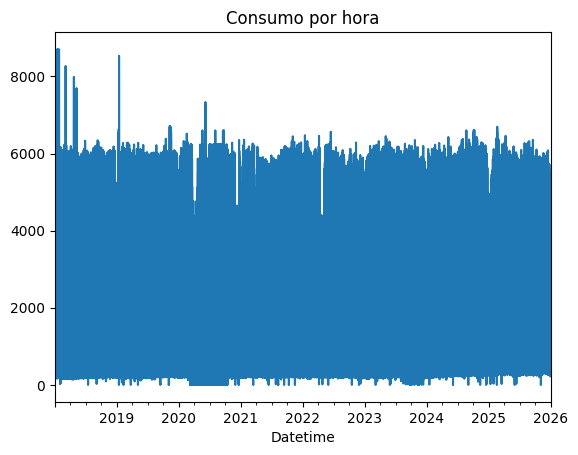

In [29]:
#Visualización por hora
serie_envigado = datos_continuos(df_env)
serie_envigado.plot(title = 'Consumo por hora')
plt.show()

In [30]:
#Visualización de los datos por día
consumo_diario_envigado = serie_envigado.resample('D').sum()
consumo_diario_envigado

,Consumo
Datetime,
2018-01-01,34910.3398
2018-01-02,68497.0165
2018-01-03,70396.3512
2018-01-04,69061.6844
2018-01-05,70737.3504
...,...
2025-12-28,41682.2442
2025-12-29,65956.6671
2025-12-30,67791.9642


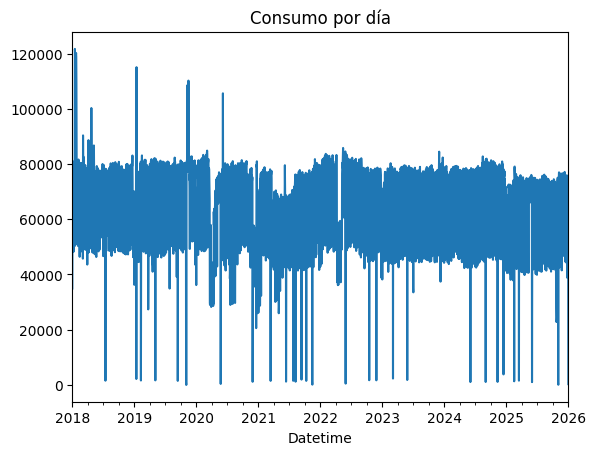

In [31]:
consumo_diario_envigado.plot(title = 'Consumo por día')
plt.show()

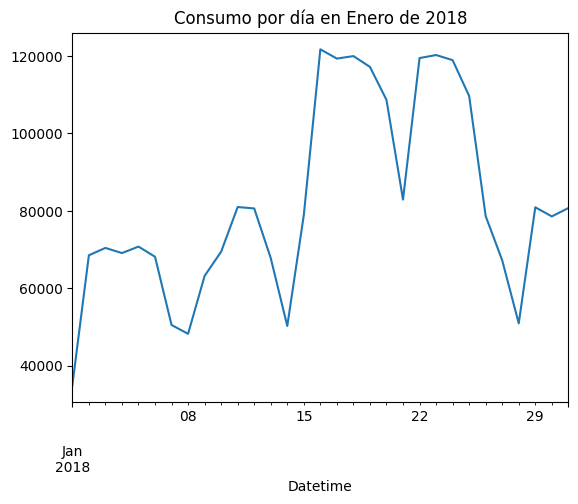

In [32]:
#Visualizar por hora durante un mes particular (enero)
consumo_diario_envigado.loc[(consumo_diario_envigado.index.month == 1) & (consumo_diario_envigado.index.year == 2018)].plot(title = 'Consumo por día en Enero de 2018')
plt.show()

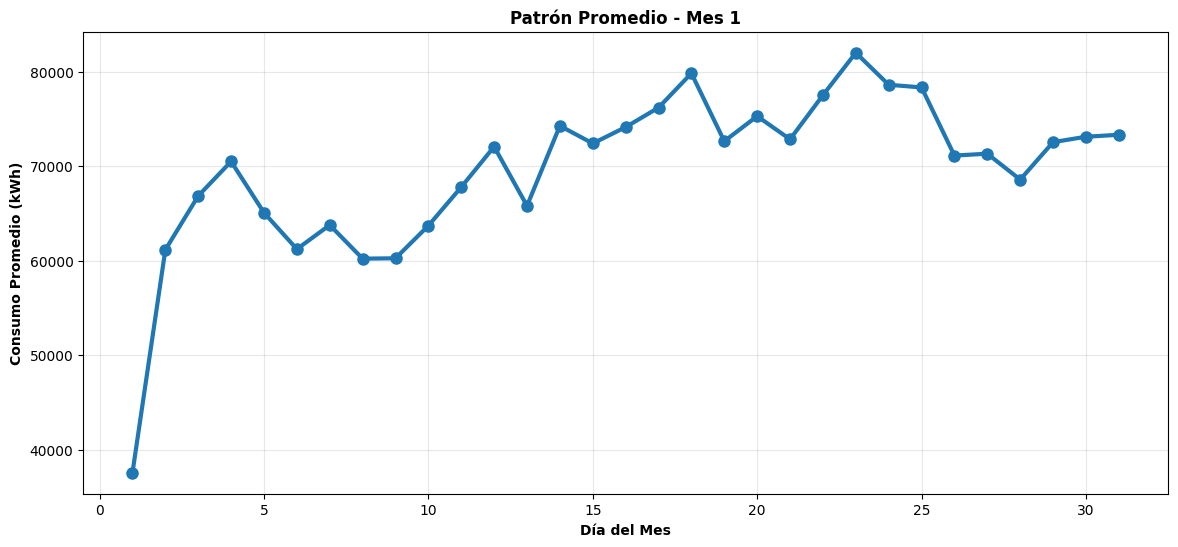

In [58]:
#Comportamiento general de un més particular durante la serie

mes = 1  # Cambia el mes aquí

#Filtrar solo el mes que queremos analizar
df_temp = df_env[df_env['Fecha'].dt.month == mes].copy()

#Extraer el día del mes (1-31)
df_temp['Día'] = df_temp['Fecha'].dt.day

# Promedio por día del mes
datos = df_temp.groupby('Día')['Total'].mean()

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(datos.index, datos.values, marker='o', linewidth=3, markersize=8)
plt.xlabel('Día del Mes', fontweight='bold')
plt.ylabel('Consumo Promedio (kWh)', fontweight='bold')
plt.title(f'Patrón Promedio - Mes {mes}', fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

**Importente:** Graficar consumos en varios meses, semanas, años, y también con otras escalas como por día, semana, etc, todo con su respectiva interpretación. También, le pueden poner sus promedios móviles.

In [33]:
#Visualización de los datos por semana
consumo_semanal_envigado = serie_envigado.resample('W').sum()
consumo_semanal_envigado

,Consumo
Datetime,
2018-01-07,432208.4373
2018-01-14,460335.4499
2018-01-21,748410.8565
2018-01-28,664832.8342
2018-02-04,515075.1250
...,...
2025-12-07,523375.2387
2025-12-14,489185.4068
2025-12-21,483931.1199


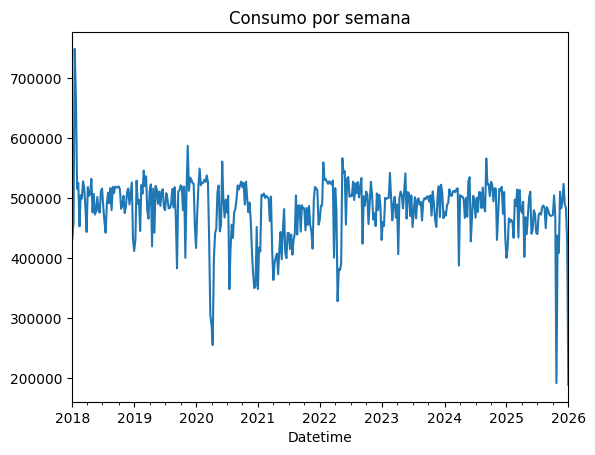

In [34]:
consumo_semanal_envigado.plot(title = 'Consumo por semana')
plt.show()

Existen diferentes ventanas temporales:

* B = día hábil

* D = día calendario

* W = semanal

* M = fin de mes

* BM = fin de mes hábil

* MS = inicio de mes

* BMS = inicio de mes hábil

* Q = fin de trimestre

* BQ = fin de trimestre hábil

* QS = inicio de trimestre

* BQS = inicio de trimestre hábil

* A = fin de año

* BA = fin de año hábil

* AS = inicio de año

* BAS = inicio de año hábil

* h = por hora

* min = por minuto

* s = por segundo

* ms = milisegundos

* us = microsegundos



In [ ]:
#Visualización de los datos por mes

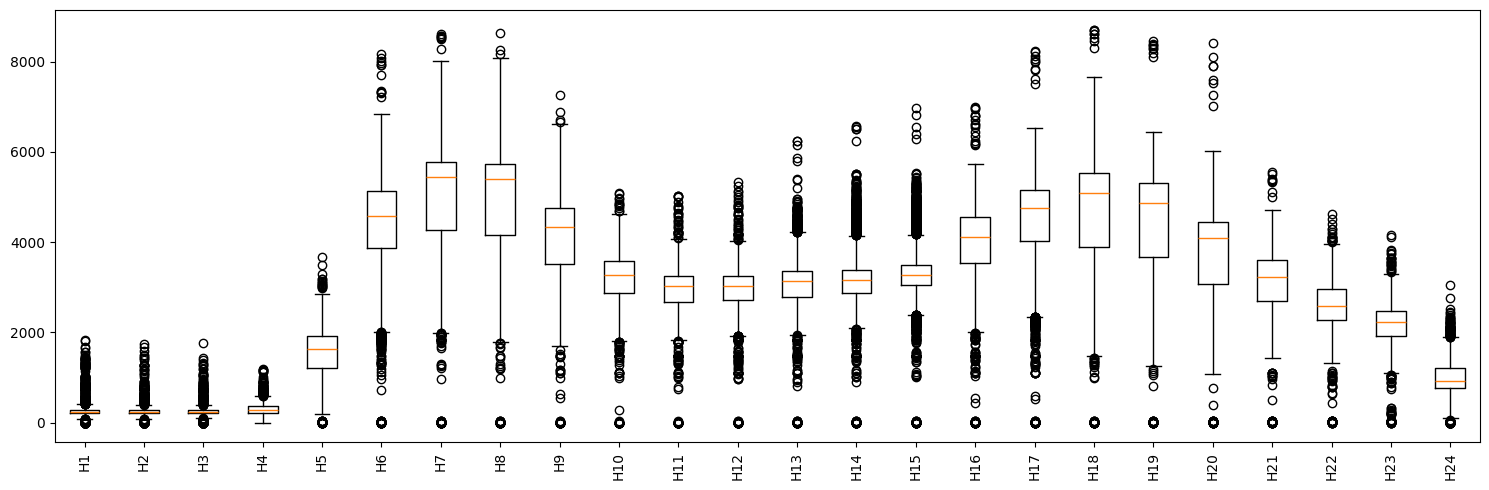

In [35]:
#Hacer un boxplot para cada columna

cols_horas = [f'H{i}' for i in range(1,25)]

plt.figure(figsize=(15,5))
plt.boxplot([df_env[col] for col in cols_horas])
plt.xticks(range(1,25), cols_horas, rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
#Diagrama de autocorrelación

In [ ]:
#Diagrama de autocorrelación parcial

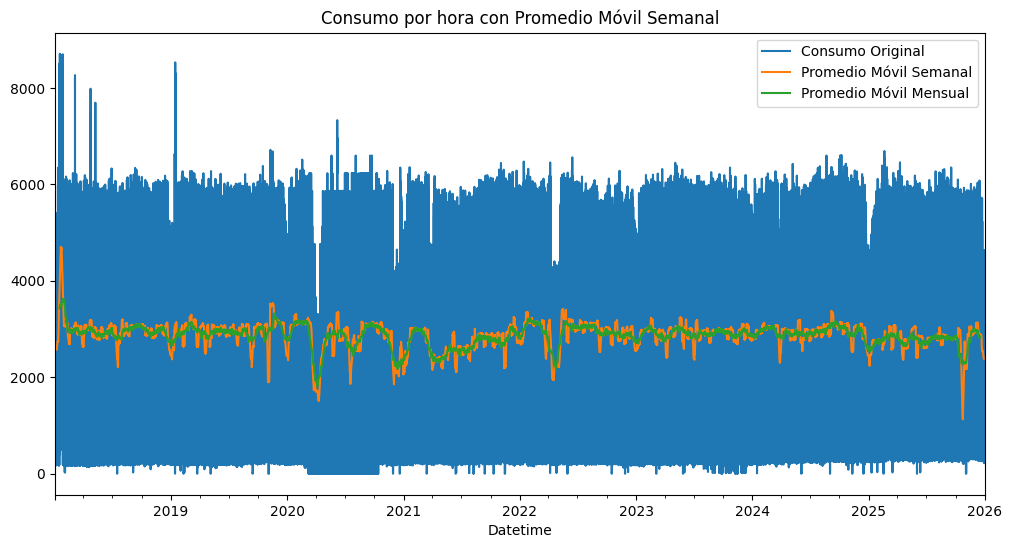

In [37]:
#Promedio móvil (hacerlo con varias ventanas de tiempo)

# Calcular el promedio móvil directamente sobre la serie. Un promedio semanal requiere 7*24 horas.
rolling_mean_semanal = serie_envigado.rolling(window=7*24, center=True).mean()
rolling_mean_mesual = serie_envigado.rolling(window=30*24, center=True).mean()


# Crear un DataFrame para plotear tanto la serie original como el promedio móvil
df_plot_rolling = pd.DataFrame({
    'Consumo Original': serie_envigado,
    'Promedio Móvil Semanal': rolling_mean_semanal,
    'Promedio Móvil Mensual': rolling_mean_mesual
})

df_plot_rolling.plot(title='Consumo por hora con Promedio Móvil Semanal', figsize=(12, 6))
plt.show()

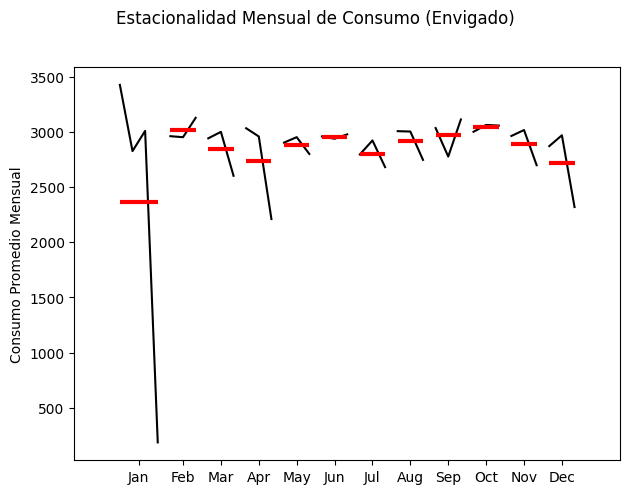

In [ ]:
#Graficas de estacionalidad (Hacerlo con varias escalas como hora, días, semanas y meses)

# 1. Estacionalidad mensual
# Resample a promedio mensual y luego plotear
fig_month = month_plot(serie_envigado.resample('ME').mean(), ylabel='Consumo Promedio Mensual')
fig_month.suptitle('Estacionalidad Mensual de Consumo (Envigado)', y=1.02)
plt.tight_layout()
plt.show()

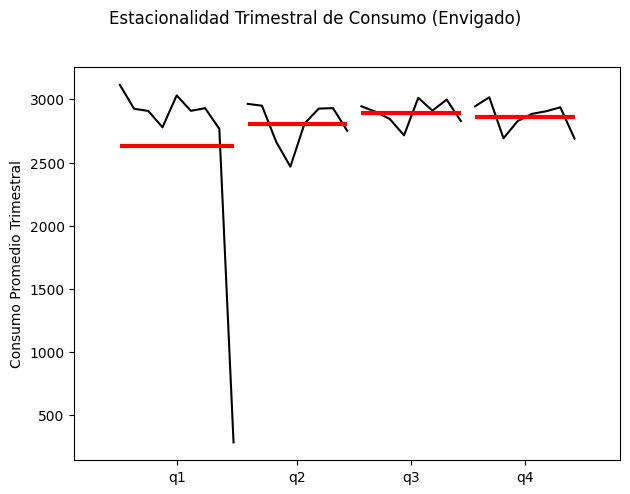

In [41]:
# 2. Estacionalidad trimestral

# Resample a promedio trimestral (inicio del trimestre) y luego plotear
fig_quarter = quarter_plot(serie_envigado.resample('QS').mean(), ylabel='Consumo Promedio Trimestral')
fig_quarter.suptitle('Estacionalidad Trimestral de Consumo (Envigado)', y=1.02)
plt.tight_layout()
plt.show()

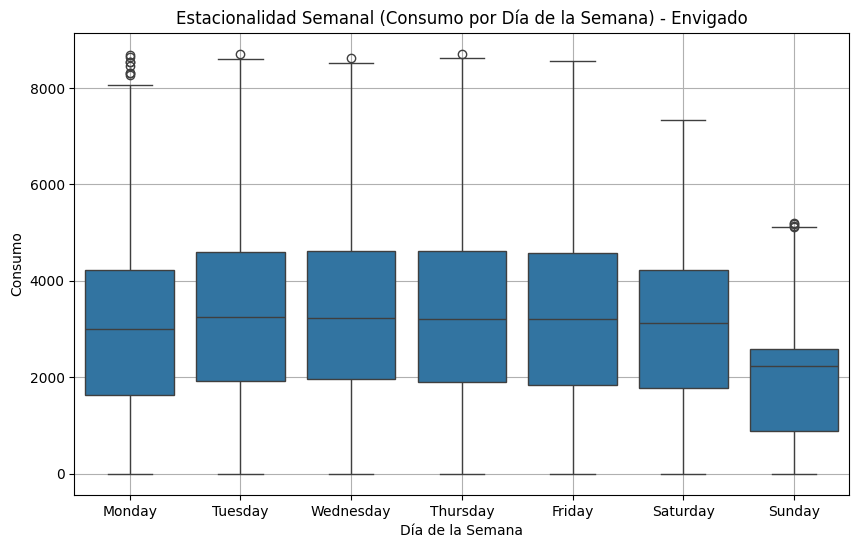

In [42]:
# Convertir la serie a DataFrame para facilitar la extracción de componentes de tiempo
df_temp = serie_envigado.copy().to_frame(name='Consumo')
df_temp['Dia_Semana'] = df_temp.index.day_name()
df_temp['Hora_Dia'] = df_temp.index.hour

# 3. Estacionalidad semanal (por día de la semana)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Dia_Semana', y='Consumo', data=df_temp, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Estacionalidad Semanal (Consumo por Día de la Semana) - Envigado')
plt.xlabel('Día de la Semana')
plt.ylabel('Consumo')
plt.grid(True)
plt.show()

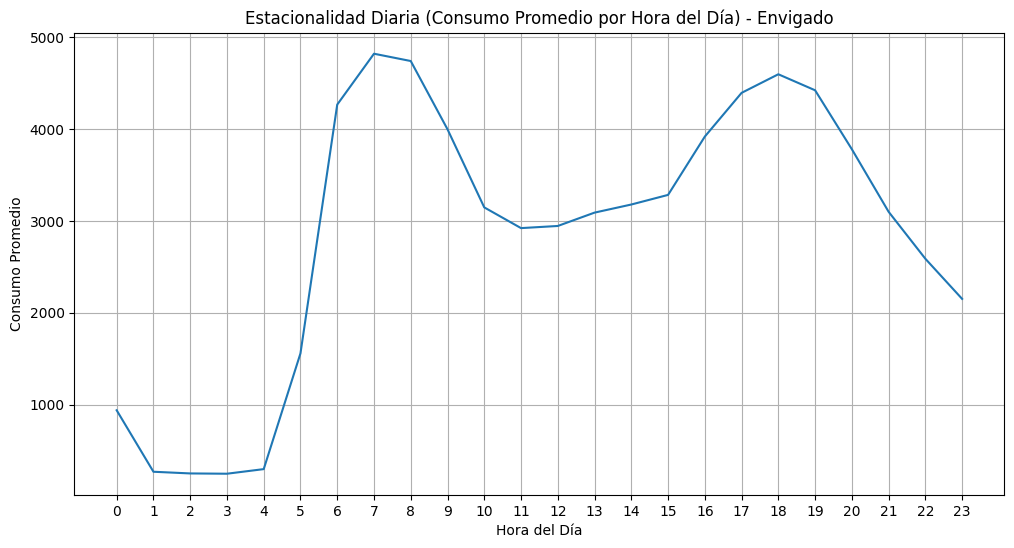

In [43]:
# 4. Estacionalidad diaria (por hora del día)
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hora_Dia', y='Consumo', data=df_temp, estimator=np.mean, errorbar=None)
plt.title('Estacionalidad Diaria (Consumo Promedio por Hora del Día) - Envigado')
plt.xlabel('Hora del Día')
plt.ylabel('Consumo Promedio')
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [ ]:
#Descomposición estacional

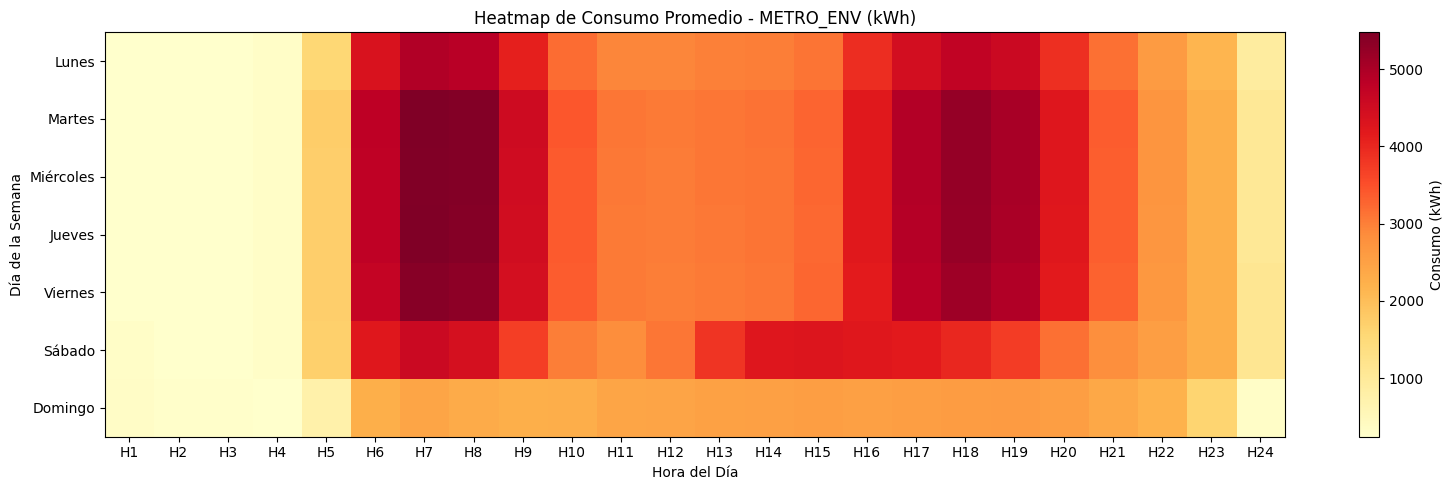

In [44]:
#Visualizaciones adicionales (diagramas de calor, etc)

#Diagrama de calor

cols_horas = [f'H{i}' for i in range(1,25)]

# Asegurar fecha en formato datetime
df = df_env.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Día de la semana (0=Lunes ... 6=Domingo)
df['dow'] = df['Fecha'].dt.dayofweek

# Promedio por día de semana
prom = df.groupby('dow')[cols_horas].mean()

# Orden y nombres bonitos
nombres = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
prom.index = [nombres[i] for i in prom.index]
prom = prom.reindex(nombres)  # fuerza orden Lunes..Domingo

# Heatmap
plt.figure(figsize=(16,5))
plt.imshow(prom.values, aspect='auto', origin='upper', cmap='YlOrRd')
plt.colorbar(label='Consumo (kWh)')
plt.xticks(range(24), cols_horas, rotation=0)
plt.yticks(range(7), nombres)
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.title('Heatmap de Consumo Promedio - METRO_ENV (kWh)')
plt.tight_layout()
plt.show()